# Base line

In [1]:
print('hello')

hello


In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [5]:
pwd


'/mnt/e/Machine Learning/Credit-Card-Fraud-Detection/src/notebook'

In [8]:
import sys
import os

# Gets the parent directory of your current notebook folder
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Adds it to the search path if it's not already there
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

In [11]:
from Enum import PathEnum

In [12]:
df = pd.read_csv(PathEnum.PathEnum.TRAIN_PATH.value) 


In [13]:
df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,119191.0,2.052427,-0.133236,-1.740621,0.277935,0.337999,-0.826933,0.334629,-0.227039,0.267655,0.293539,0.427682,0.504109,-0.989043,0.761661,-0.984511,-0.296433,-0.336666,-0.231668,0.544180,-0.269148,-0.006518,0.121300,0.037733,-0.356498,0.147822,0.569149,-0.103929,-0.091958,8.73,0
1,71750.0,1.220356,-0.159191,-0.444349,-0.094437,0.104457,-0.345790,0.170867,-0.094996,0.187572,-0.143353,-0.947576,-0.541060,-0.817426,0.564658,1.276676,0.046158,-0.176105,-0.676223,0.038731,-0.033806,-0.088775,-0.364654,-0.140851,-0.707308,0.415661,1.087767,-0.102532,-0.008335,59.95,0
2,151977.0,0.892824,-1.440698,-0.637940,3.912871,0.099291,2.433288,-0.308891,0.603227,-0.113826,1.057386,-1.317899,-0.768390,-1.081373,0.133451,0.447815,0.575453,-0.158101,-0.903597,-2.798035,0.509795,0.484969,0.487304,-0.122694,-0.598803,-0.594563,0.062841,-0.033426,0.038254,460.65,0
3,55709.0,-3.146021,2.247634,0.901397,0.146162,-2.109360,-0.148312,-1.533191,2.073663,0.499394,-0.363315,-1.072917,0.252020,-1.155591,0.742563,0.338738,0.094420,0.990406,-0.371517,-0.390559,-0.096924,0.050567,-0.037019,0.107000,0.392857,0.303597,0.379544,-0.148990,0.074965,4.78,0
4,66654.0,1.194996,-0.007495,0.301285,0.750199,-0.297494,-0.405836,0.060410,-0.150482,0.400860,-0.228237,-1.002326,0.639557,0.671282,-0.212945,-0.237918,-0.161859,-0.182514,-0.619759,0.389821,0.011447,-0.234931,-0.545566,-0.089418,-0.064036,0.527305,0.294221,-0.025980,0.015637,44.31,0


In [14]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,170884.0,94966.107886,47464.723773,0.000000,54348.000000,84923.500000,139404.000000,172792.000000
V1,170884.0,-0.001070,1.958944,-46.855047,-0.922071,0.016603,1.316250,2.451888
V2,170884.0,-0.000904,1.650481,-63.344698,-0.599127,0.065839,0.802518,22.057729
V3,170884.0,-0.002722,1.521820,-48.325589,-0.896376,0.177007,1.028302,4.226108
V4,170884.0,-0.002603,1.416490,-5.683171,-0.848978,-0.020895,0.738812,16.875344
V5,170884.0,0.000151,1.394123,-113.743307,-0.691840,-0.054185,0.612154,34.099309
V6,170884.0,0.000779,1.338331,-23.496714,-0.768986,-0.274228,0.400359,73.301626
V7,170884.0,-0.000811,1.260122,-43.557242,-0.554440,0.040417,0.569221,120.589494
V8,170884.0,-0.002327,1.208709,-73.216718,-0.209596,0.021461,0.326026,18.282168
V9,170884.0,-0.000622,1.098393,-13.434066,-0.642036,-0.051777,0.595095,10.392889


In [17]:
df.isnull().sum().sum()

np.int64(0)

In [18]:
#remove outliers 
import pandas as pd


def remove_outliers_iqr(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """Removes rows containing outliers in the specified columns using the IQR method.

    Parameters:
    - df: Input pandas DataFrame
    - columns: List of numerical column names to filter

    Returns:
    - Cleaned pandas DataFrame
    """
    df_clean = df.copy()
    for col in columns:
        q1 = df_clean[col].quantile(0.25)
        q3 = df_clean[col].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        df_clean = df_clean[
            (df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)
        ]

    return df_clean

In [19]:
df_clean = remove_outliers_iqr(df=df, columns=df.columns)

In [20]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,66044.0,95682.572861,46748.182636,0.000000,55317.500000,81274.000000,140742.250000,172784.000000
V1,66044.0,0.855864,1.112043,-3.087106,-0.275277,1.184022,1.932598,2.379970
V2,66044.0,0.082185,0.672938,-2.570286,-0.357424,0.054274,0.557672,2.775110
V3,66044.0,0.075788,1.169892,-3.184405,-0.733829,0.224789,0.939810,3.790995
V4,66044.0,0.114769,0.984804,-3.168213,-0.609781,0.219087,0.714384,3.046125
V5,66044.0,-0.123589,0.714015,-2.508760,-0.587609,-0.121507,0.360908,2.433526
V6,66044.0,-0.420995,0.598738,-2.316707,-0.836986,-0.484659,-0.044831,1.807795
V7,66044.0,0.020107,0.630779,-2.061393,-0.427884,0.060787,0.457061,2.122622
V8,66044.0,0.007957,0.276222,-0.860655,-0.184647,-0.020111,0.169510,0.880061
V9,66044.0,0.024600,0.797671,-2.342315,-0.448820,0.004035,0.515339,2.354781


In [21]:
df.shape

(170884, 31)

In [22]:
df_clean.shape

(66044, 31)

In [23]:
import pandas as pd


def clip_outliers_iqr(
    df: pd.DataFrame, columns: list[str], factor: float = 1.5
) -> pd.DataFrame:
    """Clips (caps) extreme values in specified columns using IQR bounds.

    Parameters:
    - df: Input pandas DataFrame
    - columns: List of numerical column names to process
    - factor: IQR multiplier for outlier boundaries (default is 1.5)

    Returns:
    - Modified pandas DataFrame with clipped features
    """
    df_clipped = df.copy()

    for col in columns:
        q1 = df_clipped[col].quantile(0.25)
        q3 = df_clipped[col].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - factor * iqr
        upper_bound = q3 + factor * iqr

        # Clip values below lower_bound to lower_bound, and above upper_bound to upper_bound
        df_clipped[col] = df_clipped[col].clip(
            lower=lower_bound, upper=upper_bound
        )

    return df_clipped

In [24]:
df_clipped = clip_outliers_iqr(df=df, columns=df.columns, factor=1.5)

In [25]:
df_clipped.shape

(170884, 31)

In [26]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def plot_distributions(
    df: pd.DataFrame,
    columns: list[str],
    bins: int = 30,
    figsize_per_row: tuple[int, int] = (12, 3),
) -> None:
    """Plots histograms with KDE overlay and box plots for specified numerical columns.

    Parameters:
    - df: Input pandas DataFrame
    - columns: List of numerical column names to plot
    - bins: Number of histogram bins
    - figsize_per_row: Tuple controlling width and height per feature plot
    """
    sns.set_theme(style="whitegrid")
    n_cols = len(columns)

    if n_cols == 0:
        print("No columns provided to plot.")
        return

    # Create a figure with 2 subplots per feature (Histogram + Boxplot)
    fig, axes = plt.subplots(
        nrows=n_cols,
        ncols=2,
        figsize=(figsize_per_row[0], figsize_per_row[1] * n_cols),
        gridspec_kw={"width_ratios": [3, 1]},
    )

    # Ensure axes is 2D array even for a single column
    if n_cols == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, col in enumerate(columns):
        # 1. Histogram + KDE
        sns.histplot(
            data=df,
            x=col,
            kde=True,
            bins=bins,
            ax=axes[i, 0],
            color="skyblue",
            edgecolor="black",
        )
        axes[i, 0].set_title(f"Distribution: {col}", fontsize=12, weight="bold")
        axes[i, 0].set_xlabel(col)
        axes[i, 0].set_ylabel("Count")

        # 2. Boxplot (to visually identify outliers)
        sns.boxplot(
            data=df, x=col, ax=axes[i, 1], color="salmon", fliersize=3
        )
        axes[i, 1].set_title(f"Box Plot: {col}", fontsize=12, weight="bold")
        axes[i, 1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

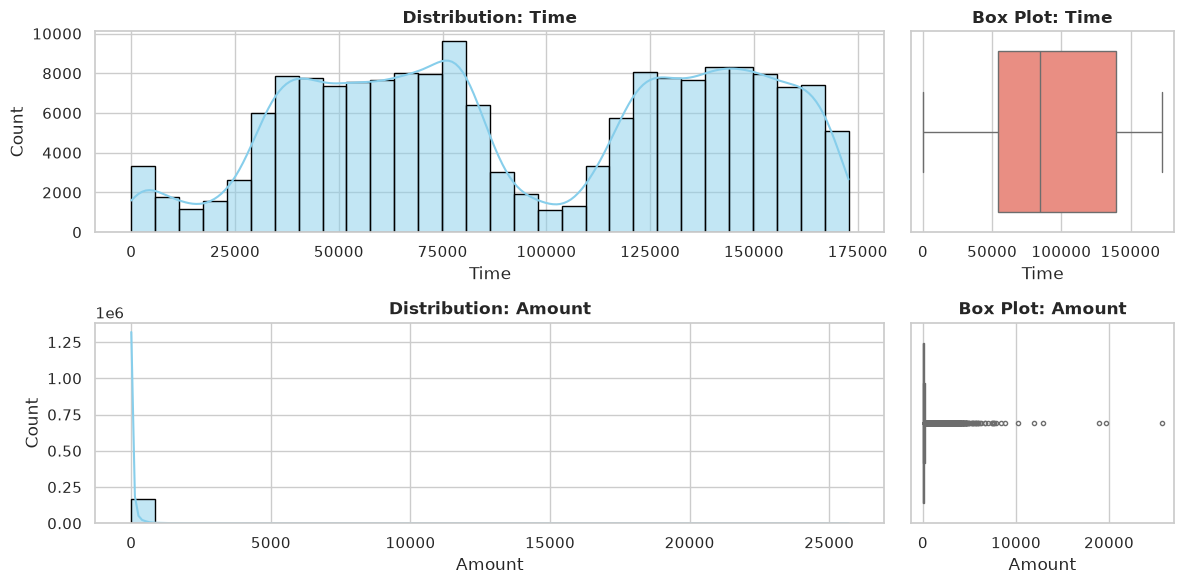

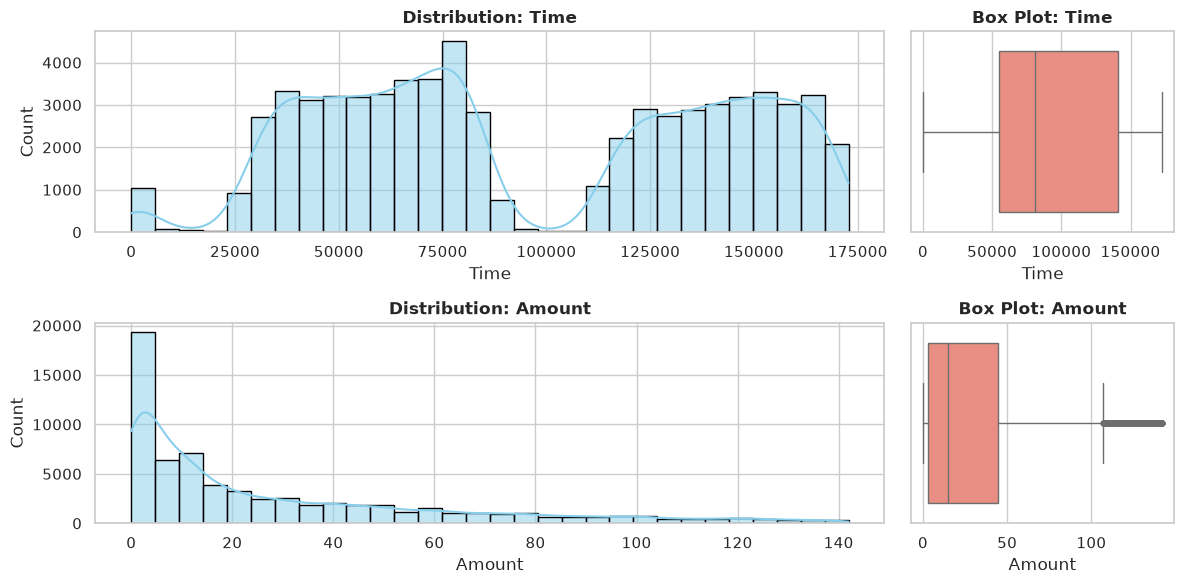

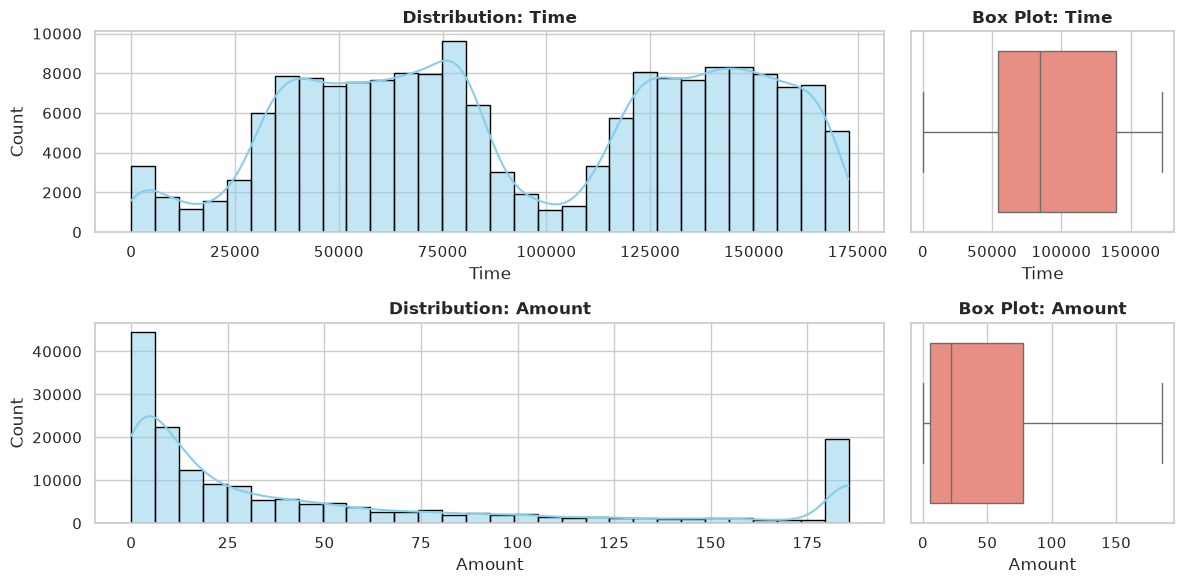

In [30]:
plot_distributions(df, columns=['Time','Amount'])
plot_distributions(df_clean, columns=['Time','Amount'])
plot_distributions(df_clipped, columns=['Time','Amount'])

In [31]:
df_clipped['log_Time'] = np.log1p(df_clipped['Time'])
df_clipped['log_Amount'] = np.log1p(df_clipped['Amount'])

In [32]:
df_clipped.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,170884.0,94966.107886,47464.723773,0.000000,54348.000000,84923.500000,139404.000000,172792.000000
V1,170884.0,0.074384,1.597900,-4.279554,-0.922071,0.016603,1.316250,2.451888
V2,170884.0,0.049167,1.122743,-2.701593,-0.599127,0.065839,0.802518,2.904985
V3,170884.0,0.024746,1.374100,-3.783393,-0.896376,0.177007,1.028302,3.915319
V4,170884.0,-0.030991,1.309390,-3.230663,-0.848978,-0.020895,0.738812,3.120496
V5,170884.0,-0.002104,1.078256,-2.647830,-0.691840,-0.054185,0.612154,2.568144
V6,170884.0,-0.090410,1.004252,-2.523005,-0.768986,-0.274228,0.400359,2.154378
V7,170884.0,0.008063,0.865636,-2.239932,-0.554440,0.040417,0.569221,2.254713
V8,170884.0,0.067656,0.486261,-1.013030,-0.209596,0.021461,0.326026,1.129460
V9,170884.0,-0.015823,1.018047,-2.497733,-0.642036,-0.051777,0.595095,2.450792


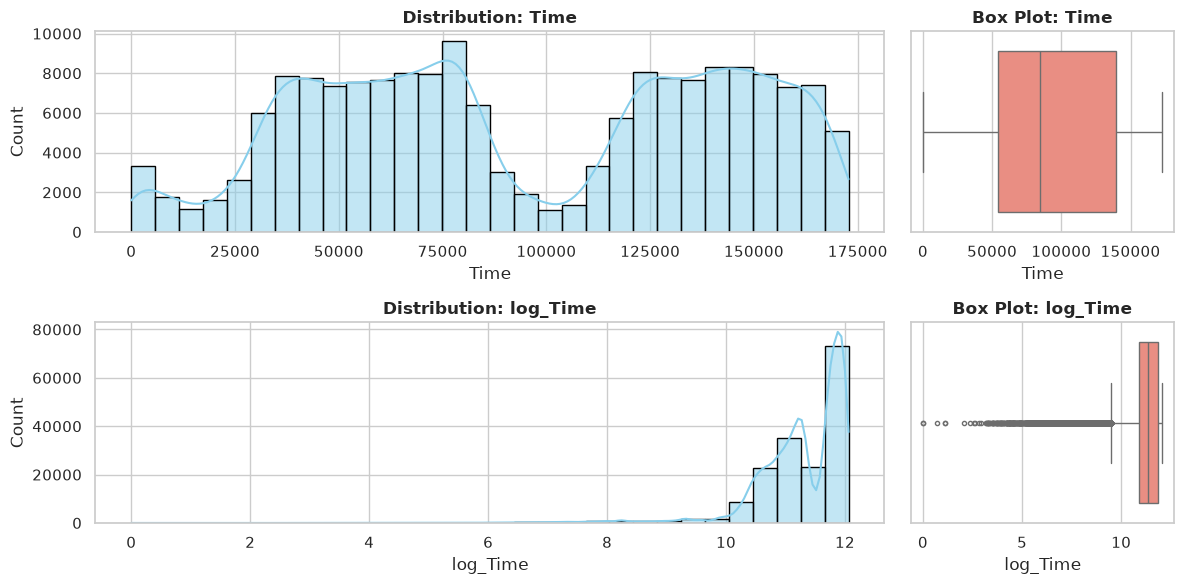

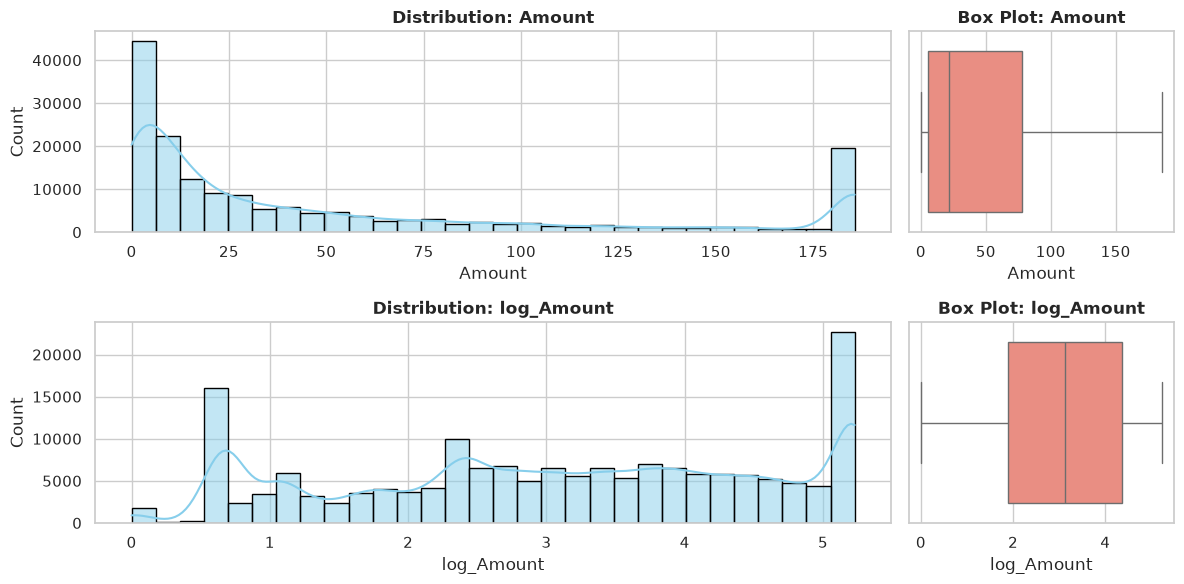

In [35]:
plot_distributions(df_clipped, columns=['Time', 'log_Time'])
plot_distributions(df_clipped, columns=['Amount', 'log_Amount'])

In [36]:
df_clipped.drop(['Time', 'Amount'], axis=1, inplace=True)

In [37]:
df_clipped.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'log_Time',
       'log_Amount'],
      dtype='str')

In [39]:
df['Class'].describe()

count    170884.000000
mean          0.001785
std           0.042210
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: Class, dtype: float64

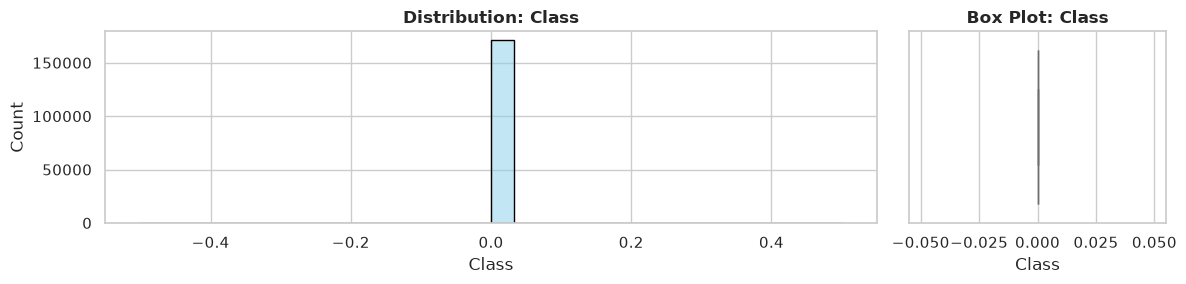

In [41]:
plot_distributions(df_clipped, ['Class'])

In [42]:
df['Class'].value_counts()

Class
0    170579
1       305
Name: count, dtype: int64

In [43]:
from sklearn.preprocessing import StandardScaler 


In [46]:
X = df_clipped.drop(['Class'] , axis=1)

In [47]:
X.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'log_Time',
       'log_Amount'],
      dtype='str')

In [54]:
y = df['Class']

In [49]:
scaler = StandardScaler() 
x_scaled = scaler.fit_transform(X)

In [53]:
y.value_counts()

Class
0    170884
Name: count, dtype: int64

In [64]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 1. Prepare Features (X) and Target (y)
# X = df.drop(columns=['target'])
# y = df['target']

# 3. Feature Scaling (CRITICAL for Logistic Regression)
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(
#     X_test
# )  # Scale test set using training parameters

# 4. Initialize and Train Logistic Regression
# Use class_weight='balanced' if your dataset is imbalanced
custome_w = {0:1.0, 1:3.0}
model = LogisticRegression(
    max_iter=1000, C=1.0, class_weight=custome_w, random_state=42
)
model.fit(x_scaled, y)

# 5. Make Predictions
y_pred = model.predict(x_scaled)
y_probs = model.predict_proba(x_scaled)[
    :, 1
]  # Probabilities for class 1

# 6. Evaluate Model
print("Confusion Matrix:\n", confusion_matrix(y, y_pred))
print("\nClassification Report:\n", classification_report(y, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y, y_probs):.4f}")

Confusion Matrix:
 [[170534     45]
 [    63    242]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    170579
           1       0.84      0.79      0.82       305

    accuracy                           1.00    170884
   macro avg       0.92      0.90      0.91    170884
weighted avg       1.00      1.00      1.00    170884

ROC-AUC Score: 0.9842


In [56]:
y.value_counts()

Class
0    170579
1       305
Name: count, dtype: int64